In [1]:
import numpy as np
import pandas as pd

In [2]:
# 如果 yfinance 下载出现 rate limit error，修改代理设置，并运行以下代码
# 详情见 https://blog.csdn.net/m0_50837851/article/details/146198595

import os
proxy = 'http://127.0.0.1:7897'	# 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy 
os.environ['HTTPS_PROXY'] = proxy 

In [4]:
import yfinance as yf

# 示例股票池（约200只，存在幸存者偏差）
tickers = [
    "AAPL","MSFT","AMZN","GOOG","GOOGL","META","NVDA","AVGO","TSLA","PEP","COST","ADBE",
    "CSCO","NFLX","AMD","INTC","TXN","QCOM","CRM","ORCL","IBM","AMAT","MU","LRCX","KLAC",
    "MA","V","PYPL","AXP","COF","BAC","JPM","C","MS","GS","BLK","WFC",
    "JNJ","PFE","MRK","ABBV","BMY","LLY","UNH","CVS","CI","HUM","ISRG",
    "XOM","CVX","COP","SLB","HAL","EOG","PSX","VLO",
    "WMT","TGT","HD","LOW","DG","DLTR","EBAY","BKNG",
    "NKE","LULU","PVH","TAP","KO","MDLZ","HSY","CL","PG","KMB","EL",
    "CAT","DE","MMM","HON","GE","ETN","EMR","DOV","ITW","PH","ROK","XYL",
    "UPS","FDX","DAL","UAL","LUV","EXPD","JBHT","CSX","UNP","NSC",
    "PLD","AMT","CCI","EQIX","DLR","O","SPG",
    "MCD","SBUX","YUM","CMG","DPZ",
    "T","VZ","TMUS",
    "F","GM","STLA","HMC","TM",
    "BA","LMT","NOC","GD","RTX",
    "A","TMO","DHR","ILMN","IDXX","ZBH","SYK","BSX","EW",
    "AON","AJG","MMC","TRV","PGR","ALL","CB","CINF",
    "SPGI","MCO","ICE","CME","MSCI","NDAQ",
    "DUK","SO","NEE","D","EXC","AEP","ED",
    "PANW","FTNT","ANET","HPE","HPQ",
    "DIS","CMCSA","WBD","ROKU",
    "APD","LIN","SHW","PPG","CE","DD",
    "GIS","K","CPB","SJM","KR","CVS",
    "BBY","ROST","TJX","ULTA","BBWI",
]

# 一次性下载
data = yf.download(tickers, start="2000-01-01", end="2025-01-01", auto_adjust=True, progress=True)
cl = data["Close"] if isinstance(data.columns, pd.MultiIndex) else data[["Close"]]
cl = cl.dropna(axis=1, how="all")
print("cl shape:", cl.shape)
cl.head()

[*********************100%***********************]  177 of 177 completed

cl shape: (6289, 177)


Ticker,A,AAPL,ABBV,ADBE,AEP,AJG,ALL,AMAT,AMD,AMT,...,V,VLO,VZ,WBD,WFC,WMT,XOM,XYL,YUM,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,43.036400,0.839281,NaN,16.274672,10.217414,7.495414,12.529693,22.908701,15.500,21.432663,...,NaN,2.324076,15.310874,NaN,9.648861,14.210652,17.255520,NaN,4.524351,NaN
2000-01-04,39.748913,0.768521,NaN,14.909398,10.339293,7.156719,12.129810,21.776833,14.625,21.204166,...,NaN,2.301291,14.815953,NaN,9.171037,13.678918,16.924999,NaN,4.433407,NaN
2000-01-05,37.283268,0.779767,NaN,15.204175,10.725233,7.186171,12.662994,20.961910,15.000,21.843948,...,NaN,2.384837,15.310874,NaN,9.078558,13.399759,17.847692,NaN,4.456143,NaN
2000-01-06,35.863667,0.712287,NaN,15.328290,10.786174,7.173287,12.596343,20.995865,16.000,21.615454,...,NaN,2.460788,15.233109,NaN,9.479313,13.545985,18.770376,NaN,4.418250,NaN
2000-01-07,38.852287,0.746027,NaN,16.072979,10.928367,7.451234,13.062876,21.176962,16.250,22.803619,...,NaN,2.430408,15.120627,NaN,9.648861,14.569581,18.715284,NaN,4.319731,NaN


In [5]:
# 工具函数
def backshift(day, x):
    assert day >= 0
    y = np.full_like(x, np.nan, dtype=float)
    y[day:] = x[:-day] if day > 0 else x
    return y

def is_last_trading_day_of_month(idx: pd.DatetimeIndex):
    month = idx.month
    next_month = np.r_[month[1:], np.nan]
    return (month != next_month)

def fill_missing(df: pd.DataFrame):
    return df.ffill().bfill()

def smartsum(arr, axis=1):
    return np.nanmean(arr, axis=axis)  # 等价于均权组合，忽略 NaN

In [6]:
cl = cl.sort_index()
cl = fill_missing(cl)

# 找月末
mask_me = is_last_trading_day_of_month(cl.index)
cl_me = cl.loc[mask_me]

# 月度收益
monthly_ret = (cl_me - cl_me.shift(1)) / cl_me.shift(1)

# 排序（升序），得到排序后的收益和对应的列索引
sort_idx = np.argsort(monthly_ret.to_numpy(), axis=1)
monthly_sorted = np.take_along_axis(monthly_ret.to_numpy(), sort_idx, axis=1)

In [7]:
monthly_sorted

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [-0.37500044, -0.25879887, -0.23117371, ...,  0.72679792,
         0.85244057,  0.9626556 ],
       [-0.35419583, -0.21141649, -0.17803053, ...,  0.53898998,
         0.57437049,  0.66384224],
       ...,
       [-0.30845616, -0.19456868, -0.18598854, ...,  0.13202498,
         0.1492298 ,  0.37153874],
       [-0.41882992, -0.14549654, -0.11179157, ...,  0.2853155 ,
         0.28905282,  0.38146886],
       [-0.24995814, -0.1791022 , -0.16781355, ...,  0.17000809,
         0.19257157,  0.43423732]], shape=(300, 177))

In [8]:
# 往前移 12 个月，作为“上一年”的排序依据
prev_sorted = backshift(12, monthly_sorted)
prev_sort_idx = backshift(12, sort_idx)

positions = np.zeros_like(monthly_ret.to_numpy())
dates_me = cl_me.index.to_numpy()

for m in range(12, monthly_ret.shape[0]):
    # 有效数据的列
    has_data = np.isfinite(prev_sorted[m, :]) & np.isfinite(cl_me.iloc[m-1].to_numpy())
    my_sort_idx = prev_sort_idx[m, has_data].astype(int)
    topN = int(np.floor(len(my_sort_idx) / 10))
    if topN < 1:
        continue
    # 前 10%（上一年最差）做空，后 10% 做多
    positions[m-1, my_sort_idx[:topN]] = -1
    positions[m-1, my_sort_idx[-topN:]] = 1

# 用滞后持仓乘当月收益，取均值（等权）
ret = smartsum(np.roll(positions, 1, axis=0) * monthly_ret.to_numpy(), axis=1)
ret = pd.Series(ret, index=cl_me.index)

avg_ann_ret = 12 * ret.mean()
sharpe = np.sqrt(12) * ret.mean() / ret.std()

print(f"Avg ann return={avg_ann_ret:7.4f} Sharpe ratio={sharpe:7.4f}")

Avg ann return= 0.0006 Sharpe ratio= 0.0366


/tmp/ipykernel_1071631/4125736463.py:17: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=axis)  # 等价于均权组合，忽略 NaN


In [9]:
ret

Date
2000-01-31         NaN
2000-02-29    0.000000
2000-03-31    0.000000
2000-04-28    0.000000
2000-05-31    0.000000
                ...   
2024-08-30    0.003604
2024-09-30   -0.005523
2024-10-31   -0.005581
2024-11-29   -0.004043
2024-12-31    0.004686
Length: 300, dtype: float64

<Axes: title={'center': 'YOY Seasonal Trending Strategy Equity Curve'}, xlabel='Date'>

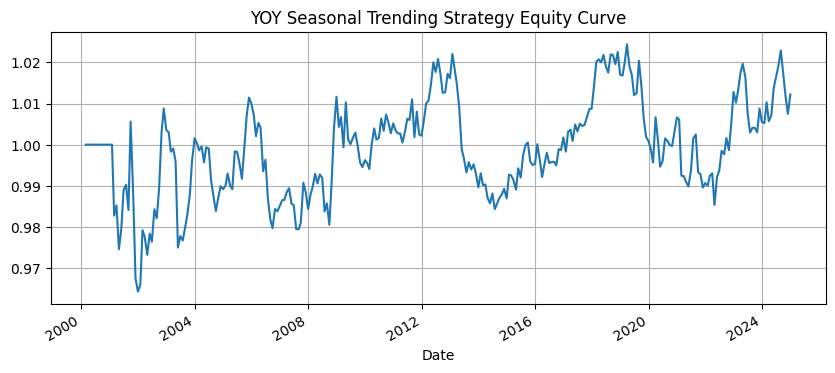

In [10]:
equity = (1 + ret).cumprod()
equity.plot(title="YOY Seasonal Trending Strategy Equity Curve", figsize=(10,4), grid=True)